# CS 46530 Learning Assignment
## Noah Glaze

### Install Dependencies
If you need to install any dependencies, change InstallOption to True below. This only needs ran **once**.

In [2]:
InstallOption = False
if InstallOption:
    !pip3 install ucimlrepo
    !pip3 install seaborn
    !pip3 install scikit-learn
    !pip3 install pandas
    !pip3 install matplotlib

## 1. Load the dataset:
This block grabs the dataset from UCI and sets it up for future manipulation

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the dataset
student_success = fetch_ucirepo(id=697)

# Extract features targets, put into one dataframe df
X = student_success.data.features
y = student_success.data.targets
df = pd.concat([X, y], axis=1)

#output first few rows to show successful retrival
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Graph of student outcomes, pre-resampling
This is only for visualization

Original Class Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


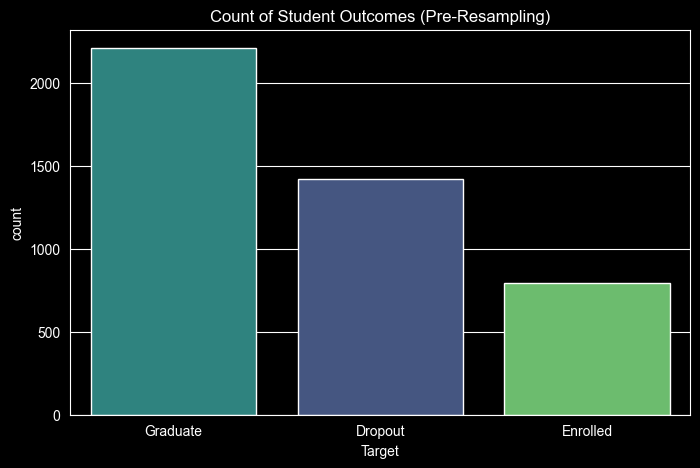

In [4]:
# Check the counts of each target
class_counts = df['Target'].value_counts()
print("Original Class Distribution:")
print(class_counts)

#
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df, palette='viridis', order=class_counts.index, hue='Target')
plt.title('Count of Student Outcomes (Pre-Resampling)')
plt.show()

## 2. Handle the imbalanced dataset
This step uses resampling to balance out the dataset. In particular, the Dropout and Enrolled counts are upsampled to match the much higher Graduate target

In [5]:
from sklearn.utils import resample

# Separate the target classes
df_graduate = df[df.Target == 'Graduate']
df_dropout = df[df.Target == 'Dropout']
df_enrolled = df[df.Target == 'Enrolled']

# Upsample Dropout to match Graduate count
df_dropout_upsampled = resample(df_dropout,
                                replace=True,
                                n_samples=len(df_graduate),
                                random_state=10)

# Upsample Enrolled to match Graduate count
df_enrolled_upsampled = resample(df_enrolled,
                                 replace=True,
                                 n_samples=len(df_graduate),
                                 random_state=11)

# Combine back into one dataset
df_balanced = pd.concat([df_graduate, df_dropout_upsampled, df_enrolled_upsampled])

print("Balanced Class Distribution:")
print(df_balanced['Target'].value_counts())

Balanced Class Distribution:
Target
Graduate    2209
Dropout     2209
Enrolled    2209
Name: count, dtype: int64


## 3. Analyze features
This figures out which features are more correlated to graduation versus dropping out. Higher numbers are more correlated to graduation, and lower numbers into the negatives are more correlated to dropping out.

In [6]:
df_numeric = df_balanced.copy()

# Map Target to numeric values
# Graduate = 1, Enrolled = 0.5, Dropout = 0.
df_numeric['Target'] = df_numeric['Target'].map({'Graduate': 1, 'Dropout': 0, 'Enrolled': 0.5})

# Calculate correlation for features against Target
corr_matrix = df_numeric.corr()
correlation_table = corr_matrix[['Target']].sort_values(by='Target', ascending=False)

correlation_table = correlation_table.drop('Target')

# Display results
print("Correlation of Features with Student Success:")
correlation_table

Correlation of Features with Student Success:


,Target
Curricular units 2nd sem (approved),0.603145
Curricular units 2nd sem (grade),0.526525
Curricular units 1st sem (approved),0.511450
Curricular units 1st sem (grade),0.442777
Tuition fees up to date,0.387538
Scholarship holder,0.265514
Curricular units 2nd sem (enrolled),0.168962
Curricular units 1st sem (enrolled),0.153366
Displaced,0.103384
Admission grade,0.100187


### Plot of highest graduation correlation
This is only for visualization

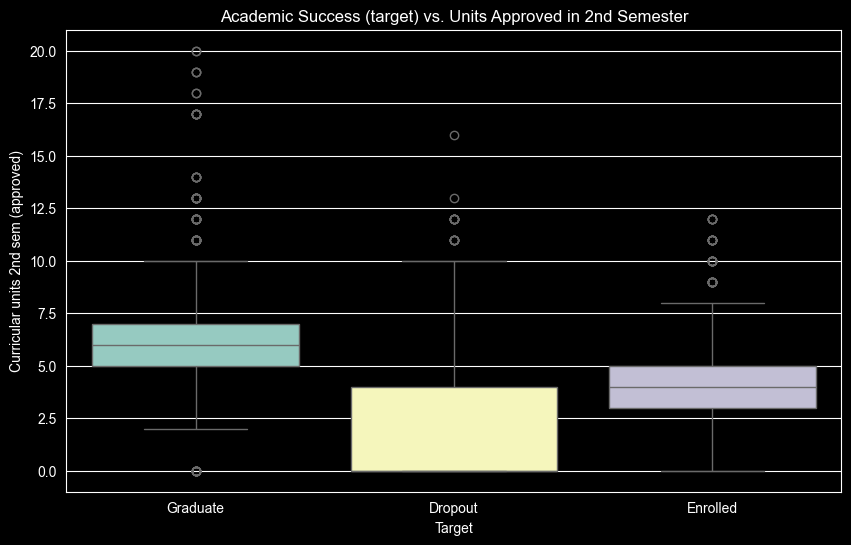

In [7]:
# Visual 2
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Curricular units 2nd sem (approved)', data=df_balanced, order=class_counts.index, hue='Target')
plt.title('Academic Success (target) vs. Units Approved in 2nd Semester')
plt.show()

## 4. Build a classifier
This step has multiple sub-sections: one for preparing the data to be classified and one for each algorithm used

Hyperparameters are automatically chosen from a selection of different options for each parameter, with the best option being used to predict the rest of the data


### 4a. Preparing the data
This does two main things: First, it splits the data into training and testing entries. Then, it scales the data to make it uniform and easier to classify

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop Target and Target_num column from features
X_final = df_balanced.drop(['Target'], axis=1)
y_final = df_balanced['Target']

# Split data according to UCI recommendation (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=12)

# Scale data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4b. Decision Tree
Classifies data using a decision tree and displays results with scikit-learn's own report function

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=13), dt_param_grid, cv=5, scoring='f1_macro')
dt_grid.fit(X_train_scaled, y_train)

print(f"Best Decision Tree Hyperparameters: {dt_grid.best_params_}")
dt_predict = dt_grid.predict(X_test_scaled)

print("Decision Tree Report")
print(classification_report(y_test, dt_predict))

Best Decision Tree Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Decision Tree Report
              precision    recall  f1-score   support

     Dropout       0.89      0.93      0.91       440
    Enrolled       0.88      0.92      0.90       454
    Graduate       0.88      0.80      0.84       432

    accuracy                           0.88      1326
   macro avg       0.88      0.88      0.88      1326
weighted avg       0.88      0.88      0.88      1326



### 4c. Support Vector Machine

In [10]:
from sklearn.svm import SVC

svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['poly', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(random_state=14), svm_param_grid, cv=5, scoring='f1_macro')
svm_grid.fit(X_train_scaled, y_train)

print(f"Best SVM Params: {svm_grid.best_params_}")
svm_predict = svm_grid.predict(X_test_scaled)

print("SVM Report:")
print(classification_report(y_test, svm_predict))

Best SVM Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM Report:
              precision    recall  f1-score   support

     Dropout       0.89      0.83      0.86       440
    Enrolled       0.80      0.81      0.80       454
    Graduate       0.80      0.84      0.82       432

    accuracy                           0.83      1326
   macro avg       0.83      0.83      0.83      1326
weighted avg       0.83      0.83      0.83      1326



### 4d. Nearest Neighbors

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {
    'n_neighbors': [3, 5, 11, 21],
    'weights': ['uniform', 'distance'],
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='f1_macro')
knn_grid.fit(X_train_scaled, y_train)

print(f"Best KNN Params: {knn_grid.best_params_}")
knn_predict = knn_grid.predict(X_test_scaled)

print("Nearest Neighbors Report:")
print(classification_report(y_test, knn_predict))

Best KNN Params: {'n_neighbors': 21, 'weights': 'distance'}
Nearest Neighbors Report:
              precision    recall  f1-score   support

     Dropout       0.96      0.88      0.92       440
    Enrolled       0.77      0.96      0.85       454
    Graduate       0.91      0.75      0.83       432

    accuracy                           0.87      1326
   macro avg       0.88      0.86      0.86      1326
weighted avg       0.88      0.87      0.87      1326



## 5. comparison

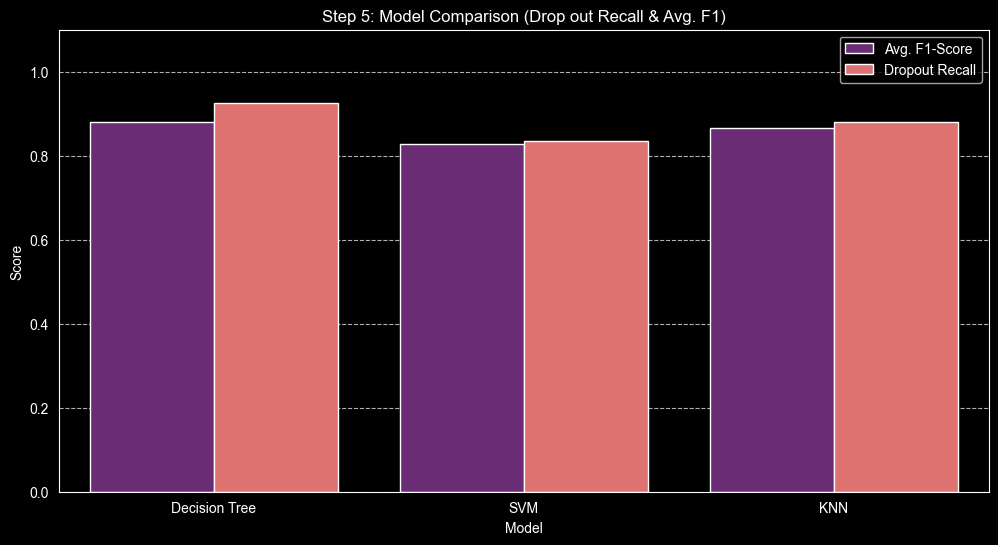

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score, f1_score

def get_minority_metrics(y_true, y_predict, model_name):
    f1 = f1_score(y_true, y_predict, average='macro')
    recall_dropout = recall_score(y_true, y_predict, labels=['Dropout'], average='macro')
    return {'Model': model_name, 'Avg. F1-Score': f1, 'Dropout Recall': recall_dropout}

results = [
    get_minority_metrics(y_test, dt_predict, 'Decision Tree'),
    get_minority_metrics(y_test, svm_predict, 'SVM'),
    get_minority_metrics(y_test, knn_predict, 'KNN')
]

performance_df = pd.DataFrame(results)

plot_data = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_data, palette='magma')
plt.ylim(0, 1.1)
plt.title('Step 5: Model Comparison (Drop out Recall & Avg. F1)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()